In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [27]:
df.isnull().sum()

age                                 9
sex                                 0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
NUmber_of_past_hospitalizations     2
Anual_Salary                        6
region                              0
charges                             0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.dropna(inplace = True)

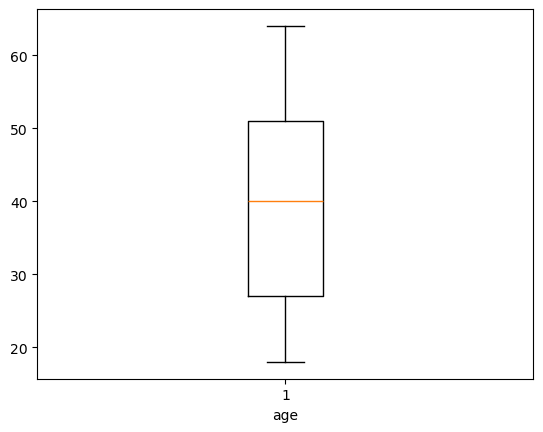

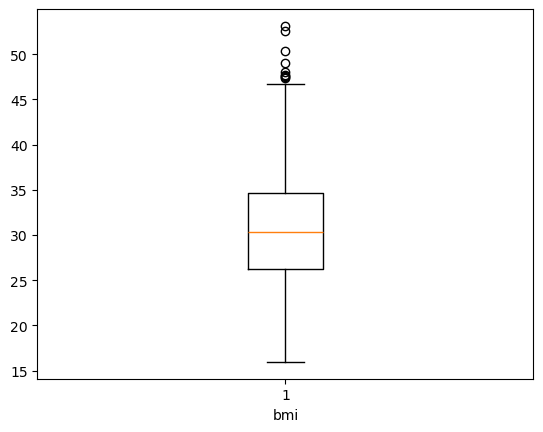

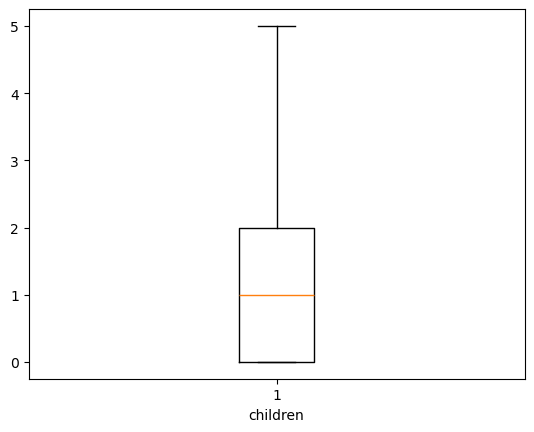

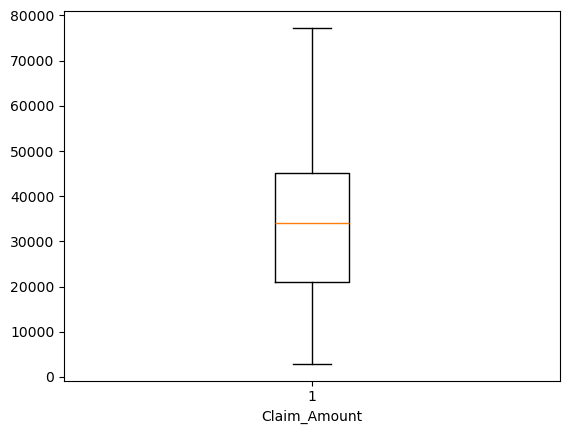

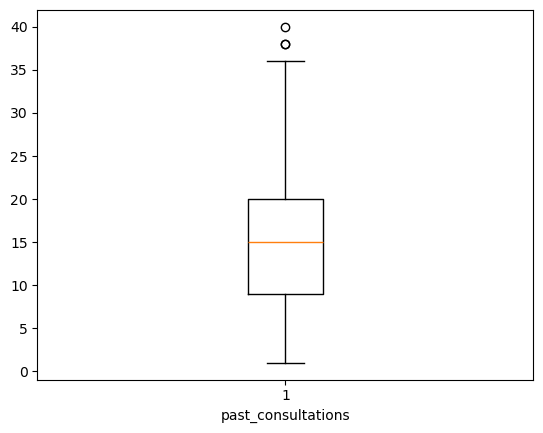

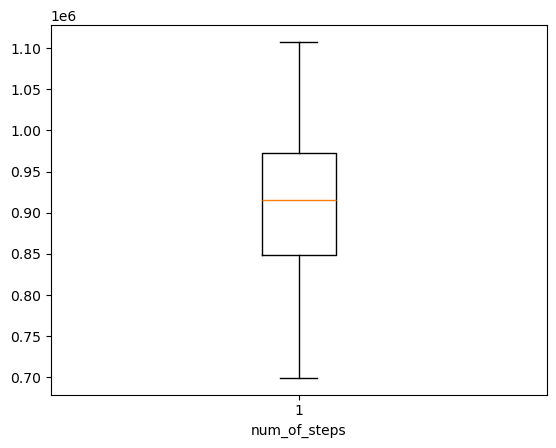

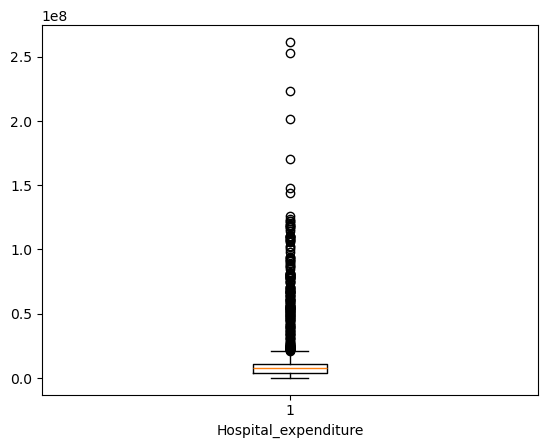

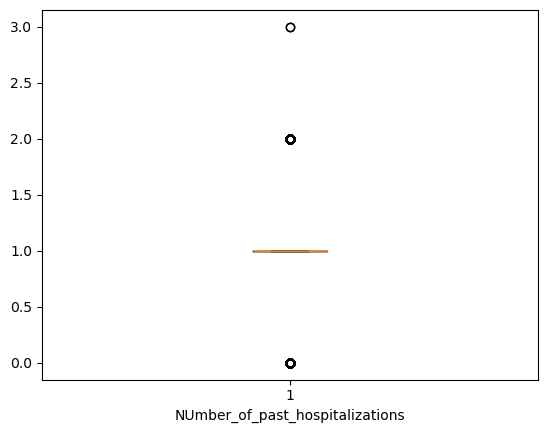

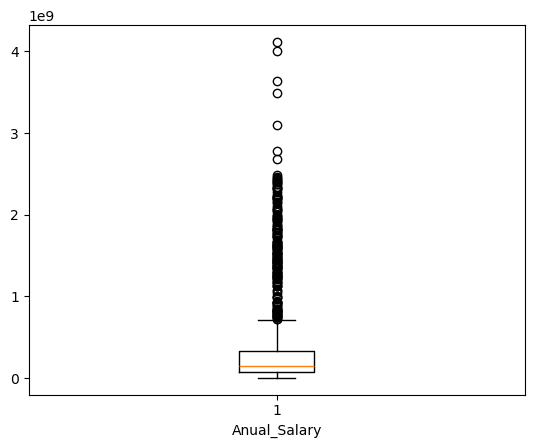

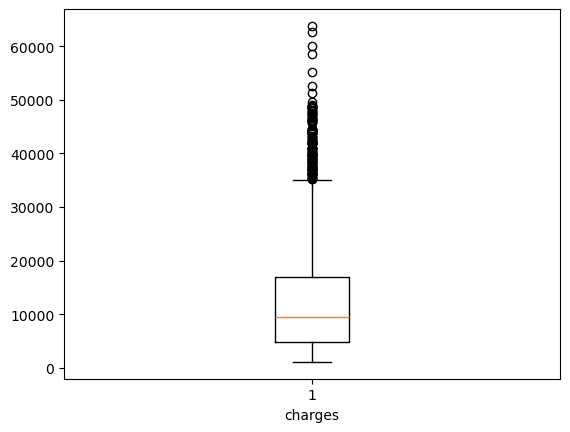

In [30]:
#check for outliers
for i in df.columns:
    if df[i].dtype != 'object':
        plt.boxplot(df[i])
        plt.xlabel(i)
        plt.show()

In [31]:
#Label encoding - convert categorical columns to numerical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [32]:
mapping = {}
for i in df.columns:
    if df[i].dtype == 'object':
        df[i] = le.fit_transform(df[i])
        mapping[i] = dict(zip(le.classes_,le.transform(le.classes_)))
print(mapping)

{'sex': {'female': np.int64(0), 'male': np.int64(1)}, 'smoker': {'no': np.int64(0), 'yes': np.int64(1)}, 'region': {'northeast': np.int64(0), 'northwest': np.int64(1), 'southeast': np.int64(2), 'southwest': np.int64(3)}}


In [33]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2,1121.87390
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2,1131.50660
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2,1135.94070
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2,1136.39940
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,0,35.530,0.0,1,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,1,55135.40209
1334,31.0,0,38.095,1.0,1,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,0,58571.07448
1335,52.0,1,34.485,3.0,1,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,1,60021.39897
1336,45.0,1,30.360,0.0,1,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,2,62592.87309


In [11]:
#importing linear regression model
#get the independent and dependent variables separately, x is independent variables, y is dependent variables
x = df.iloc[:,:-1]
y = df['charges']

In [14]:
#random_state is used to control how randomly the data is shuffled
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.20,random_state = 42)

In [15]:
x_train

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
385,33.0,0,22.135,1.0,0,46843.852750,9.0,862971.0,3.387965e+06,1.0,3.085097e+07,0
1134,53.0,0,22.610,3.0,1,24935.684530,27.0,1011897.0,2.327974e+07,2.0,6.876712e+08,0
803,52.0,0,44.700,3.0,0,41327.384140,8.0,930768.0,2.155938e+06,1.0,2.025629e+08,3
149,27.0,1,32.670,0.0,0,24052.521520,20.0,781100.0,4.761177e+06,0.0,3.107687e+07,2
295,31.0,0,29.260,1.0,0,4149.950486,9.0,853818.0,5.459474e+06,1.0,9.507359e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1088,42.0,0,26.600,0.0,1,16643.204160,10.0,990923.0,9.841898e+06,1.0,4.999114e+08,1
1139,50.0,1,32.110,2.0,0,18311.545680,29.0,997836.0,1.691774e+07,2.0,7.070238e+08,0
1174,64.0,0,26.885,0.0,1,30108.718630,32.0,1020022.0,3.175397e+07,2.0,8.837401e+08,1
902,62.0,1,39.930,0.0,0,39266.350810,12.0,935723.0,3.371662e+06,1.0,2.079527e+08,2


In [16]:
#Linear regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [17]:
#use the train data to train the model
#fit to train the model
model.fit(x_train,y_train)
#predict to test the model. Test the model
y_pred = model.predict(x_test)
y_pred

array([44621.00270114,  5316.13149102, 14795.07099845,  7543.39703808,
       40121.20032352, 13198.08907354,  4383.22752072,  7863.14773939,
        3912.45711469,  7545.58298446, 10979.60922468,  7025.00962704,
         522.06596967,  1096.90909889,  4693.48945605,  5045.87858216,
        9428.10827764,  6668.86737901,  3925.15374877, 33006.07783215,
        8542.77885753,  7998.40727268,  9927.19443169,  9298.79482662,
        4658.24908776,  2857.9502042 ,  7371.96648894,  4923.64328839,
        9144.73818845,  7284.59030821,  1055.46422817, 44521.99450108,
       10196.02915857,  1901.95772466, 25487.67032837, 12990.80973908,
        1662.1815218 , 31501.35293695, 21792.37454252, 11909.56813038,
        7001.84118046, 33897.46891424, 18828.31986107,  -220.0170832 ,
        7885.96735049, 48002.77814103,  5192.45317508,  1877.1446609 ,
       11219.82771436, 38496.41627176,  5970.96271352, 10349.84055842,
        2261.97329927,  1720.50502818,  5999.68771589, 17724.19968544,
      

In [18]:
# Evaluate how the model is performing. Comparison to be done
new_df = pd.DataFrame()
new_df['Actual Value'] = y_test
new_df['Predicted Value'] = y_pred
new_df

,Actual Value,Predicted Value
1294,44260.74990,44621.002701
358,4992.37640,5316.131491
980,15006.57945,14795.070998
446,6272.47720,7543.397038
1251,39611.75770,40121.200324
...,...,...
838,11881.96960,11396.071555
571,8023.13545,7916.617875
1035,18765.87545,19051.804381
900,12979.35800,12777.227881


In [20]:
#Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score
mean_squared_error(y_test,y_pred)

989199.4201909703

In [21]:
#If r2_score is closer to 0, then the model is working fine
r2_score(y_test,y_pred)

0.9937167161970074

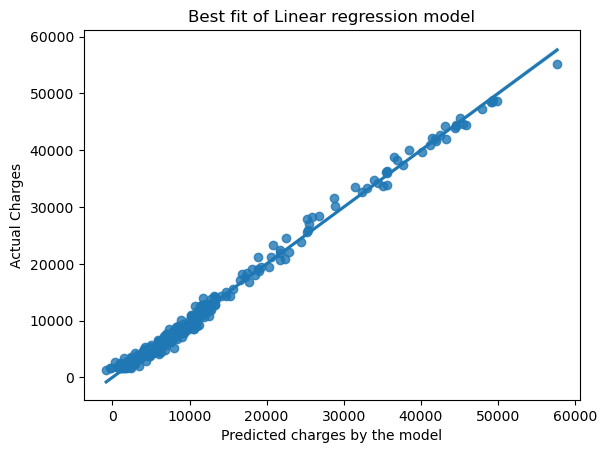

In [23]:
sns.regplot(x= y_pred, y= y_test)
plt.xlabel("Predicted charges by the model")
plt.ylabel('Actual Charges')
plt.title("Best fit of Linear regression model")
plt.show()

In [34]:
#14-June_2026
#VIF - Variance Inflation factor
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [40]:
#Create a list of all numerical columns from the dataset
col_list = []
for i in df.columns:
    if (df[i].dtype != 'object') & (i != 'charges'):
        col_list.append(i)
x = df[col_list]
vif_data = pd.DataFrame()
vif_data['Column Names'] = x.columns
#VIF values should be passed via an array to the DF
vif_data['VIF Score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]

In [41]:
vif_data

,Column Names,VIF Score
0,age,13.710629
1,sex,2.009831
2,bmi,30.159136
3,children,1.972347
4,smoker,4.073851
5,Claim_Amount,6.952488
6,past_consultations,8.593570
7,num_of_steps,71.160415
8,Hospital_expenditure,30.397183
9,NUmber_of_past_hospitalizations,17.904578


In [42]:
df=df.drop(['num_of_steps'],axis=1)

In [43]:
col_list=[]
for i in df.columns:
  if ((df[i].dtype!='object') & (i!='charges')):
    col_list.append(i)

x=df[col_list]
vif_data=pd.DataFrame()
vif_data['Columns Name']=x.columns
vif_data['VIF Score']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data

,Columns Name,VIF Score
0,age,10.736430
1,sex,1.984762
2,bmi,14.403274
3,children,1.955069
4,smoker,3.553972
5,Claim_Amount,6.464483
6,past_consultations,7.933581
7,Hospital_expenditure,30.250111
8,NUmber_of_past_hospitalizations,15.564821
9,Anual_Salary,46.506789


In [44]:
df=df.drop(['Anual_Salary'],axis=1)

In [45]:
col_list=[]
for i in df.columns:
  if ((df[i].dtype!='object') & (i!='charges')):
    col_list.append(i)

x=df[col_list]
vif_data=pd.DataFrame()
vif_data['Columns Name']=x.columns
vif_data['VIF Score']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data

,Columns Name,VIF Score
0,age,10.728714
1,sex,1.984411
2,bmi,13.717810
3,children,1.937420
4,smoker,2.899118
5,Claim_Amount,6.463172
6,past_consultations,7.761744
7,Hospital_expenditure,2.958474
8,NUmber_of_past_hospitalizations,12.990020
9,region,2.914537


In [46]:
df=df.drop(['bmi'],axis=1)

In [47]:
col_list=[]
for i in df.columns:
  if ((df[i].dtype!='object') & (i!='charges')):
    col_list.append(i)

x=df[col_list]
vif_data=pd.DataFrame()
vif_data['Columns Name']=x.columns
vif_data['VIF Score']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data

,Columns Name,VIF Score
0,age,9.413509
1,sex,1.895469
2,children,1.929162
3,smoker,2.788492
4,Claim_Amount,5.842162
5,past_consultations,7.171586
6,Hospital_expenditure,2.956974
7,NUmber_of_past_hospitalizations,12.780571
8,region,2.581048


In [48]:
df=df.drop(['NUmber_of_past_hospitalizations'],axis=1)

In [49]:
col_list=[]
for i in df.columns:
  if ((df[i].dtype!='object') & (i!='charges')):
    col_list.append(i)

x=df[col_list]
vif_data=pd.DataFrame()
vif_data['Columns Name']=x.columns
vif_data['VIF Score']=[variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data

,Columns Name,VIF Score
0,age,6.691831
1,sex,1.893288
2,children,1.805392
3,smoker,2.500650
4,Claim_Amount,5.588845
5,past_consultations,6.928823
6,Hospital_expenditure,2.641633
7,region,2.580397


In [51]:
df

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region,charges
0,18.0,1,0.0,0,29087.54313,17.0,4.720921e+06,2,1121.87390
1,18.0,1,0.0,0,39053.67437,7.0,4.329832e+06,2,1131.50660
2,18.0,1,0.0,0,39023.62759,19.0,6.884861e+06,2,1135.94070
3,18.0,1,0.0,0,28185.39332,11.0,4.274774e+06,2,1136.39940
4,18.0,1,0.0,0,14697.85941,16.0,3.787294e+06,2,1137.01100
...,...,...,...,...,...,...,...,...,...
1333,33.0,0,0.0,1,63142.25346,32.0,1.703805e+08,1,55135.40209
1334,31.0,0,1.0,1,43419.95227,31.0,2.015152e+08,0,58571.07448
1335,52.0,1,3.0,1,52458.92353,25.0,2.236450e+08,1,60021.39897
1336,45.0,1,0.0,1,69927.51664,34.0,2.528924e+08,2,62592.87309


In [52]:
x=df.iloc[:,:-1]   #iloc[row_index,column_index]
y=df['charges']

In [53]:
x # independent variables

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
0,18.0,1,0.0,0,29087.54313,17.0,4.720921e+06,2
1,18.0,1,0.0,0,39053.67437,7.0,4.329832e+06,2
2,18.0,1,0.0,0,39023.62759,19.0,6.884861e+06,2
3,18.0,1,0.0,0,28185.39332,11.0,4.274774e+06,2
4,18.0,1,0.0,0,14697.85941,16.0,3.787294e+06,2
...,...,...,...,...,...,...,...,...
1333,33.0,0,0.0,1,63142.25346,32.0,1.703805e+08,1
1334,31.0,0,1.0,1,43419.95227,31.0,2.015152e+08,0
1335,52.0,1,3.0,1,52458.92353,25.0,2.236450e+08,1
1336,45.0,1,0.0,1,69927.51664,34.0,2.528924e+08,2


In [54]:
y #Dependent variable

0        1121.87390
1        1131.50660
2        1135.94070
3        1136.39940
4        1137.01100
           ...     
1333    55135.40209
1334    58571.07448
1335    60021.39897
1336    62592.87309
1337    63770.42801
Name: charges, Length: 1287, dtype: float64

In [55]:
#Train test split
from sklearn.model_selection import train_test_split

In [56]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [57]:
x_train

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
385,33.0,0,1.0,0,46843.852750,9.0,3.387965e+06,0
1134,53.0,0,3.0,1,24935.684530,27.0,2.327974e+07,0
803,52.0,0,3.0,0,41327.384140,8.0,2.155938e+06,3
149,27.0,1,0.0,0,24052.521520,20.0,4.761177e+06,2
295,31.0,0,1.0,0,4149.950486,9.0,5.459474e+06,2
...,...,...,...,...,...,...,...,...
1088,42.0,0,0.0,1,16643.204160,10.0,9.841898e+06,1
1139,50.0,1,2.0,0,18311.545680,29.0,1.691774e+07,0
1174,64.0,0,0.0,1,30108.718630,32.0,3.175397e+07,1
902,62.0,1,0.0,0,39266.350810,12.0,3.371662e+06,2


In [58]:
y_train

385      5354.07465
1134    24873.38490
803     11411.68500
149      2497.03830
295      4350.51440
           ...     
1088    21348.70600
1139    25333.33284
1174    29330.98315
902     12982.87470
1170    28923.13692
Name: charges, Length: 1029, dtype: float64

In [59]:
x_test

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
1294,54.0,1,2.0,1,42578.49702,24.0,9.188836e+07,2
358,34.0,0,0.0,0,41670.67337,14.0,4.885269e+06,0
980,27.0,0,2.0,1,53898.22700,24.0,1.084433e+07,0
446,41.0,1,1.0,0,31306.81681,18.0,4.480321e+06,2
1251,27.0,1,0.0,1,30297.68145,18.0,6.927088e+07,2
...,...,...,...,...,...,...,...,...
838,55.0,0,2.0,0,9056.42148,24.0,6.361727e+06,2
571,44.0,0,1.0,0,13556.49516,16.0,2.347968e+06,1
1035,30.0,0,3.0,1,51184.01187,18.0,1.124054e+07,1
900,62.0,1,0.0,0,19540.95064,25.0,1.024265e+07,3


In [60]:
y_test

1294    44260.74990
358      4992.37640
980     15006.57945
446      6272.47720
1251    39611.75770
           ...     
838     11881.96960
571      8023.13545
1035    18765.87545
900     12979.35800
1143    25678.77845
Name: charges, Length: 258, dtype: float64

In [61]:
#Linear Regression
from sklearn.linear_model import  LinearRegression
model = LinearRegression()

In [62]:
#Train the Model
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
#Test the Model
y_pred=model.predict(x_test)

In [64]:
y_pred

array([44354.43520032,  7956.17893189, 22322.4628056 ,  9027.19621674,
       32000.80212621,  8988.28100864,  5285.48022246, 10424.30040375,
        5990.70715634,  8076.97116355, 11393.78488541,  8968.74811157,
        1660.17671131,  3800.50944519,  3289.67361781,  9102.51040675,
       11350.43042914,  7013.49403161,  7275.56416036, 27515.85130744,
       13347.02401746,  8236.08055301, 10642.15747278,  6629.87768455,
        7793.82865942,  5337.19465012,  8888.06364236,  5283.47260295,
        9088.14073271, 11042.41134836,  3475.59430341, 39837.76370741,
       12785.24703828,  2711.58723887, 27363.47295077, 15047.62399758,
         881.7489988 , 22461.66127077, 21615.66669506, 10310.28008753,
        8957.9399632 , 29422.51301081, 23191.51071298,  1679.43029529,
        9738.76200927, 50053.73224966,  4324.99306822,  3140.56239907,
        9999.8599239 , 38378.15760282,  8463.57690741, 10106.34269061,
        5808.86646904,  2555.45146697,  4113.21041177,  8142.81009362,
      

In [65]:
#Now compare it
new_df=pd.DataFrame()
new_df['Actual Value']=y_test
new_df['Predicted Value']=y_pred

In [66]:
new_df

,Actual Value,Predicted Value
1294,44260.74990,44354.435200
358,4992.37640,7956.178932
980,15006.57945,22322.462806
446,6272.47720,9027.196217
1251,39611.75770,32000.802126
...,...,...
838,11881.96960,12473.991516
571,8023.13545,8248.233460
1035,18765.87545,21750.375055
900,12979.35800,14186.693470


In [67]:
#Evaluation Metrics
from sklearn.metrics import  mean_squared_error
from sklearn.metrics import  r2_score

In [68]:
mean_squared_error(y_test,y_pred)

11924953.106946373

In [69]:
print(model.coef_)

[ 1.76963578e+02 -1.23800022e+02  3.49009298e+02  1.10752418e+04
  4.78691878e-02  1.88769497e+02  2.28014235e-04 -2.79785867e+02]


In [70]:
r2_score(y_test,y_pred)

0.9242540349509536

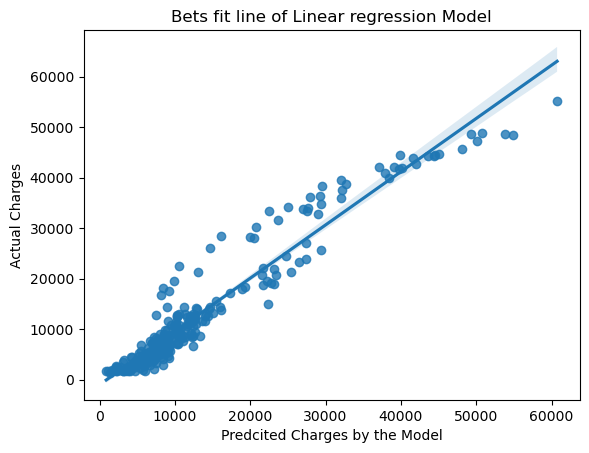

In [71]:
sns.regplot(x=y_pred,y=y_test)
plt.xlabel('Predcited Charges by the Model')
plt.ylabel('Actual Charges')
plt.title('Bets fit line of Linear regression Model')
plt.show()

In [81]:
def predict_charges():
    print('Please enter the values to predict the charges')
#age	sex	children	smoker	Claim_Amount	past_consultations	Hospital_expenditure	region
    #Asking the user to enter all these values of independent variables
    age = int(input('Enter your age:'))
    sex = int(input('Enter your sex:'))
    children = float(input('Enter the number of children:'))
    smoker = int(input('Enter whether you smoke or not:'))
    Claim_Amount = float(input('Enter the Claim amount:'))
    past_consultations = float(input('Enter the past consultations:'))
    Hospital_expenditure = float(input('Enter the Hospital expenditure:'))
    region = int(input('Enter your region:'))

    #Create a df to pass the input variables to the model as independent variables
    input_data = pd.DataFrame({
    'age': [age], 
    'sex': [sex], 
    'children': [children],
    'smoker': [smoker],               
    'Claim_Amount': [Claim_Amount], 
    'past_consultations': [past_consultations], 
    'Hospital_expenditure': [Hospital_expenditure], 
    'region': [region]
})
    predict_charges_values = model.predict(input_data)
    print("The predicted value of the charges is:",predict_charges_values)

predict_charges()

Please enter the values to predict the charges


Enter your age: 27
Enter your sex: 1
Enter the number of children: 0
Enter whether you smoke or not: 0
Enter the Claim amount: 364745
Enter the past consultations: 32
Enter the Hospital expenditure: 2543564
Enter your region: 1


The predicted value of the charges is: [24643.06246863]


In [82]:
#Build a Linear Regression model to predict Revenue of the hotel
hotel_df = pd.read_csv("revenue_prediction (1).csv")
hotel_df

,Id,Name,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
0,101,HungryHowie'sPizza,Yes,Mexican,Bengaluru,55,5.5,5953753
1,102,CharleysPhillySteaks,No,Varied Menu,Gurugram,72,6.8,7223131
2,103,Chuy's,Yes,Chicken,Pune,25,1.9,2555379
3,104,O'Charley's,Yes,Italian/Pizza,Mumbai,18,2.5,2175511
4,105,PolloTropical,Yes,Pizza,Noida,48,4.2,4816715
...,...,...,...,...,...,...,...,...
95,196,Wetzel'sPretzels,No,Italian/Pizza,Bengaluru,19,1.1,1270499
96,197,LaMadeleineCountryFrenchCafe,Yes,Varied Menu,Bengaluru,75,6.3,6412623
97,198,Giordano's,Yes,Varied Menu,Gurugram,77,6.2,6694797
98,199,IslandsFineBurgers&Drinks,Yes,Sports Bar,Pune,25,2.1,2344689


In [83]:
hotel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            100 non-null    int64  
 1   Name          100 non-null    object 
 2   Franchise     100 non-null    object 
 3   Category      100 non-null    object 
 4   City          100 non-null    object 
 5   No_Of_Item    100 non-null    int64  
 6   Order_Placed  100 non-null    float64
 7   Revenue       100 non-null    int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 6.4+ KB


In [85]:
hotel_df.isnull().sum()

Id              0
Name            0
Franchise       0
Category        0
City            0
No_Of_Item      0
Order_Placed    0
Revenue         0
dtype: int64

In [86]:
hotel_df.duplicated().sum()

np.int64(0)

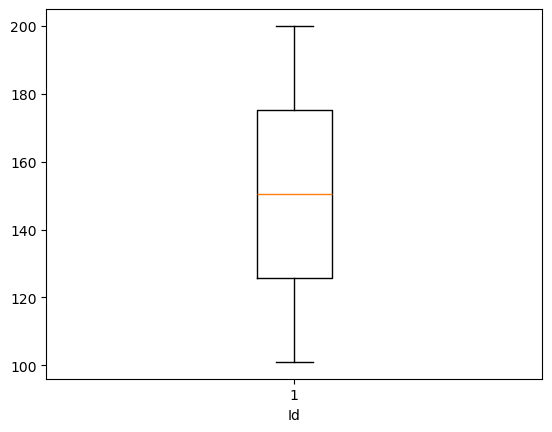

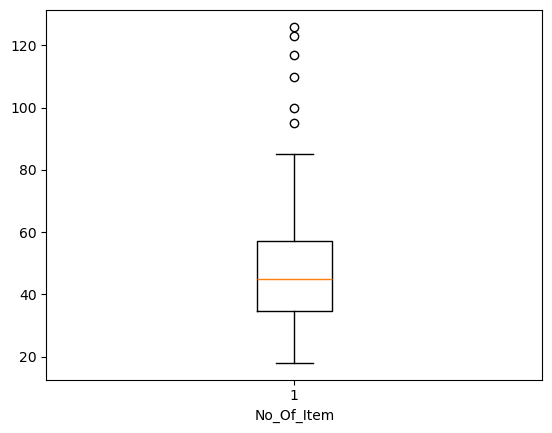

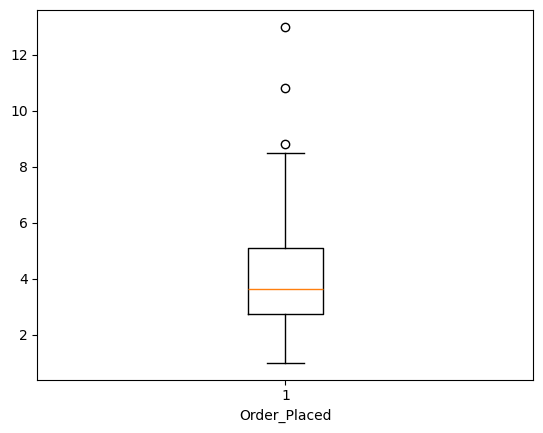

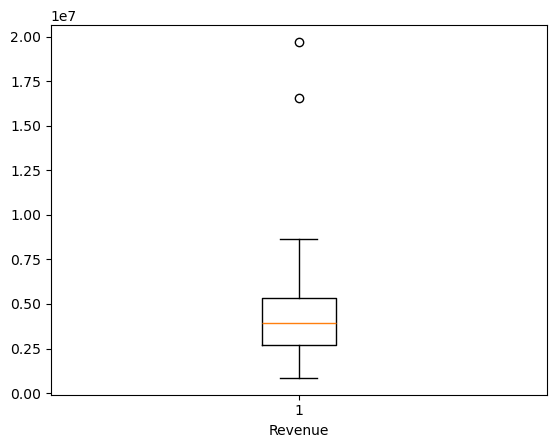

In [87]:
#check for outliers
for i in hotel_df.columns:
    if hotel_df[i].dtype != 'object':
        plt.boxplot(hotel_df[i])
        plt.xlabel(i)
        plt.show()

In [88]:
#Label encoding - convert categorical columns to numerical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [90]:
mapping = {}
hotel_df = hotel_df.drop(['Id','Name'], axis = 1)
for i in hotel_df.columns:
    if hotel_df[i].dtype == 'object':
        hotel_df[i] = le.fit_transform(hotel_df[i])
        mapping[i] = dict(zip(le.classes_,le.transform(le.classes_)))
print(mapping)

{'Franchise': {'No': np.int64(0), 'Yes': np.int64(1)}, 'Category': {'Asian': np.int64(0), 'Asian/Noodle': np.int64(1), 'BBQ': np.int64(2), 'Bakery Cafe': np.int64(3), 'Burger': np.int64(4), 'Chicken': np.int64(5), 'Coffee Cafe': np.int64(6), 'Family Casual': np.int64(7), 'Family Style': np.int64(8), 'Frozen Desserts': np.int64(9), 'Healthy': np.int64(10), 'Italian/Pizza': np.int64(11), 'Mexican': np.int64(12), 'Pizza': np.int64(13), 'Sandwich': np.int64(14), 'Seafood': np.int64(15), 'Snack': np.int64(16), 'Sports Bar': np.int64(17), 'Steak': np.int64(18), 'Varied Menu': np.int64(19)}, 'City': {'Bengaluru': np.int64(0), 'Gurugram': np.int64(1), 'Mumbai': np.int64(2), 'Noida': np.int64(3), 'Pune': np.int64(4)}}


In [91]:
hotel_df

,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
0,1,12,0,55,5.5,5953753
1,0,19,1,72,6.8,7223131
2,1,5,4,25,1.9,2555379
3,1,11,2,18,2.5,2175511
4,1,13,3,48,4.2,4816715
...,...,...,...,...,...,...
95,0,11,0,19,1.1,1270499
96,1,19,0,75,6.3,6412623
97,1,19,1,77,6.2,6694797
98,1,17,4,25,2.1,2344689


In [92]:
#Create a list of all numerical columns from the dataset
col_list = []
for i in hotel_df.columns:
    if (hotel_df[i].dtype != 'object') & (i != 'Revenue'):
        col_list.append(i)
x = hotel_df[col_list]
vif_data = pd.DataFrame()
vif_data['Column Names'] = x.columns
#VIF values should be passed via an array to the DF
vif_data['VIF Score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data

,Column Names,VIF Score
0,Franchise,2.023259
1,Category,3.854742
2,City,1.960766
3,No_Of_Item,109.458973
4,Order_Placed,97.294515


In [93]:
hotel_df = hotel_df.drop(['No_Of_Item'], axis = 1)

In [94]:
col_list = []
for i in hotel_df.columns:
    if (hotel_df[i].dtype != 'object') & (i != 'Revenue'):
        col_list.append(i)
x = hotel_df[col_list]
vif_data = pd.DataFrame()
vif_data['Column Names'] = x.columns
#VIF values should be passed via an array to the DF
vif_data['VIF Score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
vif_data

,Column Names,VIF Score
0,Franchise,2.012094
1,Category,3.411032
2,City,1.933192
3,Order_Placed,3.305379


In [95]:
hotel_df

,Franchise,Category,City,Order_Placed,Revenue
0,1,12,0,5.5,5953753
1,0,19,1,6.8,7223131
2,1,5,4,1.9,2555379
3,1,11,2,2.5,2175511
4,1,13,3,4.2,4816715
...,...,...,...,...,...
95,0,11,0,1.1,1270499
96,1,19,0,6.3,6412623
97,1,19,1,6.2,6694797
98,1,17,4,2.1,2344689


In [96]:
x=hotel_df.iloc[:,:-1]   #iloc[row_index,column_index]
y=hotel_df['Revenue']

In [97]:
x #Independent variables

,Franchise,Category,City,Order_Placed
0,1,12,0,5.5
1,0,19,1,6.8
2,1,5,4,1.9
3,1,11,2,2.5
4,1,13,3,4.2
...,...,...,...,...
95,0,11,0,1.1
96,1,19,0,6.3
97,1,19,1,6.2
98,1,17,4,2.1


In [98]:
y #Dependent variable

0     5953753
1     7223131
2     2555379
3     2175511
4     4816715
       ...   
95    1270499
96    6412623
97    6694797
98    2344689
99    4567678
Name: Revenue, Length: 100, dtype: int64

In [99]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [100]:
x_train

,Franchise,Category,City,Order_Placed
55,0,14,2,6.8
88,1,4,2,1.9
26,0,18,0,2.1
42,1,1,0,4.8
69,0,16,3,3.3
...,...,...,...,...
60,0,12,0,3.0
71,0,19,2,4.0
14,0,14,0,1.8
92,1,19,0,6.5


In [101]:
x_test

,Franchise,Category,City,Order_Placed
83,0,10,2,5.7
53,0,18,3,5.4
70,0,11,3,3.8
45,1,4,0,3.6
44,1,18,0,4.0
39,0,13,2,3.7
22,1,14,3,3.8
80,0,19,0,3.5
10,0,9,0,3.6
0,1,12,0,5.5


In [102]:
y_train

55    6941173
88    2025297
26    2967425
42    4952255
69    3452382
       ...   
60    3164972
71    4136425
14    1099097
92    6782425
51    3273041
Name: Revenue, Length: 80, dtype: int64

In [103]:
y_test

83    5966193
53    5595267
70    3982767
45    3752885
44    4264176
39    3818055
22    4956086
80    3727364
10    3945135
0     5953753
18    4937526
30    2408199
73    3347767
33    2371202
90    3426169
4     4816715
76    4590423
77    1904842
12    2234634
31    2358644
Name: Revenue, dtype: int64

In [104]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [105]:
#Test the Model
y_pred=model.predict(x_test)
y_pred

array([6219550.65445801, 5513060.16073453, 3802408.85544997,
       4270093.14561072, 4314418.97542316, 3713545.93436438,
       3915390.53860462, 3473234.46011014, 3906768.93412386,
       6311270.57564911, 5353085.82417941, 2987749.52584018,
       2769957.18754031, 2311708.41539876, 3576242.80937002,
       4429108.60903996, 5176922.97288294, 1509180.94661722,
       1795381.24155861, 2157200.18235397])

In [106]:
#Now compare it
new_df=pd.DataFrame()
new_df['Actual Value']=y_test
new_df['Predicted Value']=y_pred
new_df

,Actual Value,Predicted Value
83,5966193,6.219551e+06
53,5595267,5.513060e+06
70,3982767,3.802409e+06
45,3752885,4.270093e+06
44,4264176,4.314419e+06
39,3818055,3.713546e+06
22,4956086,3.915391e+06
80,3727364,3.473234e+06
10,3945135,3.906769e+06
0,5953753,6.311271e+06


In [107]:
mean_squared_error(y_test,y_pred)

170706666211.9353

In [108]:
print(model.coef_)

[ 206860.13127923  -31292.81604153  -94329.02459591 1206063.13598453]


In [109]:
r2_score(y_test,y_pred)

0.8834175243392675

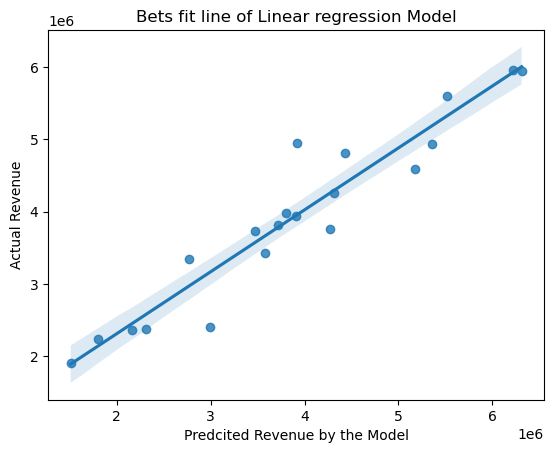

In [110]:
sns.regplot(x=y_pred,y=y_test)
plt.xlabel('Predcited Revenue by the Model')
plt.ylabel('Actual Revenue')
plt.title('Bets fit line of Linear regression Model')
plt.show()